In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import f_oneway
import seaborn as sns
from scipy.stats import spearmanr

In [2]:
#importation des fichiers csv depuis le drive
from google.colab import drive
drive.mount('/content/drive')

customers = pd.read_csv('/content/drive/MyDrive/OC/customers.csv',sep=';')
products = pd.read_csv('/content/drive/MyDrive/OC/products.csv',sep=';')
transactions = pd.read_csv('/content/drive/MyDrive/OC/Transactions.csv',sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-2758441830.py:7: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('/content/drive/MyDrive/OC/Transactions.csv',sep=';')


# Exploration de customers



In [3]:
# Affichage de customers
customers

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
...,...,...,...
8616,c_7920,m,1956
8617,c_7403,f,1970
8618,c_5119,m,1974
8619,c_5643,f,1968


In [4]:
# caractéristiques de customers
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [5]:
# describe sur customers
customers.describe(include="all")

,client_id,sex,birth
count,8621,8621,8621.000000
unique,8621,2,NaN
top,c_84,f,NaN
freq,1,4490,NaN
mean,NaN,NaN,1978.275606
std,NaN,NaN,16.917958
min,NaN,NaN,1929.000000
25%,NaN,NaN,1966.000000
50%,NaN,NaN,1979.000000
75%,NaN,NaN,1992.000000


In [6]:
# connaitre le nombre de clients par sexe
display(customers['sex'].value_counts())

,count
sex,
f,4490
m,4131


# Exploration de products

In [7]:
# affichage de products
products

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3281,2_23,115.99,2
3282,0_146,17.14,0
3283,0_802,11.22,0
3284,1_140,38.56,1


In [8]:
# caractéristiques de products
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [9]:
# describe sur products
products.describe(include="all")

,id_prod,price,categ
count,3286,3286.000000,3286.000000
unique,3286,NaN,NaN
top,0_1920,NaN,NaN
freq,1,NaN,NaN
mean,NaN,21.863597,0.370359
std,NaN,29.849786,0.615446
min,NaN,0.620000,0.000000
25%,NaN,6.990000,0.000000
50%,NaN,13.075000,0.000000
75%,NaN,22.990000,1.000000


In [10]:
# Nombre de produits proposés par catégorie
products['categ'].value_counts()

,count
categ,
0,2308
1,739
2,239


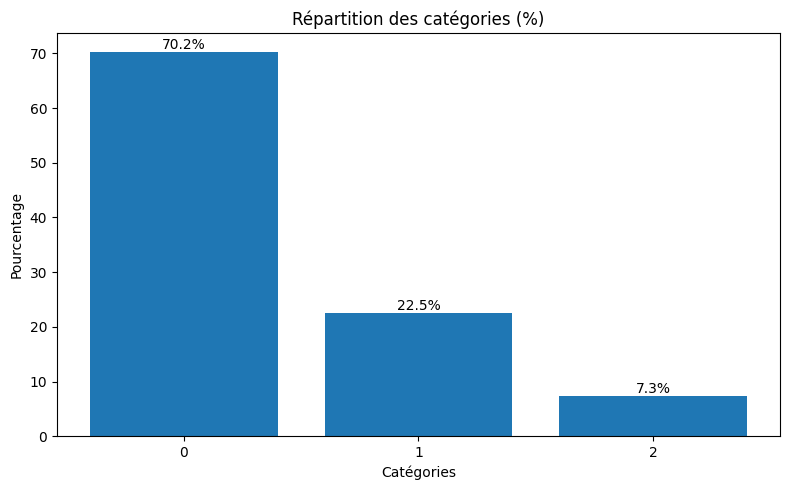

In [11]:
#visualisation graphique
import matplotlib.pyplot as plt

values = products['categ'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))

positions = range(len(values))
bars = plt.bar(positions, values)

plt.xticks(positions, values.index)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title('Répartition des catégories (%)')
plt.xlabel('Catégories')
plt.ylabel('Pourcentage')
plt.tight_layout()
plt.show()



# Analyse de transactions

In [12]:
# affichage transactions
transactions

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033
...,...,...,...,...
1048570,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN


In [13]:
# caractéristiques de transactions
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [14]:
# describe sur transactions
transactions.describe(include="all")

,id_prod,date,session_id,client_id
count,687534,687534,687534,687534
unique,3265,687419,345505,8600
top,1_369,2021-10-03 11:54:55.781188,s_118668,c_1609
freq,2340,2,14,25586


In [15]:
#affichage des lignes ou id_prod est null
transactions[transactions['id_prod'].isnull()]

,id_prod,date,session_id,client_id
687534,NaN,NaN,NaN,NaN
687535,NaN,NaN,NaN,NaN
687536,NaN,NaN,NaN,NaN
687537,NaN,NaN,NaN,NaN
687538,NaN,NaN,NaN,NaN
...,...,...,...,...
1048570,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN


In [16]:
# suppression des id_prod est null
transactions_clean = transactions.dropna(subset=['id_prod'])

In [17]:
# caractéristiques de transactions_clean
transactions_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


In [18]:
# voir les lignes identiques
transactions_clean.duplicated().sum()

np.int64(0)

In [19]:
#On change le format date en datetime
transactions_clean['date'] = pd.to_datetime(transactions_clean['date'])
transactions_clean.loc[:,'annee']=transactions_clean["date"].dt.year
transactions_clean.loc[:,'mois']=transactions_clean['date'].dt.month
transactions_clean.loc[:,'jour']=transactions_clean["date"].dt.day
transactions_clean.loc[:,'annee_mois'] = transactions_clean['annee'].astype(str) + "-" + transactions_clean['mois'].astype(str)
transactions_clean['annee_mois'] = pd.to_datetime(transactions_clean['annee_mois'])

/tmp/ipython-input-847006526.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_clean['date'] = pd.to_datetime(transactions_clean['date'])
/tmp/ipython-input-847006526.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_clean.loc[:,'annee']=transactions_clean["date"].dt.year
/tmp/ipython-input-847006526.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

In [20]:
transactions_clean['weekday'] = transactions_clean['date'].dt.day_name()


/tmp/ipython-input-2256346140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_clean['weekday'] = transactions_clean['date'].dt.day_name()


In [21]:
# Créer une colonne 'annee_mois_jour' au format YYYY-MM-DD
transactions_clean['annee_mois_jour'] = (
    transactions_clean['annee'].astype(str) + "-" +
    transactions_clean['mois'].astype(str).str.zfill(2) + "-" +
    transactions_clean['jour'].astype(str).str.zfill(2)
)

transactions_clean['annee_mois_jour'] = pd.to_datetime(transactions_clean['annee_mois_jour'])

/tmp/ipython-input-534197844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_clean['annee_mois_jour'] = (
/tmp/ipython-input-534197844.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions_clean['annee_mois_jour'] = pd.to_datetime(transactions_clean['annee_mois_jour'])


In [22]:
transactions_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_prod          687534 non-null  object        
 1   date             687534 non-null  datetime64[ns]
 2   session_id       687534 non-null  object        
 3   client_id        687534 non-null  object        
 4   annee            687534 non-null  int32         
 5   mois             687534 non-null  int32         
 6   jour             687534 non-null  int32         
 7   annee_mois       687534 non-null  datetime64[ns]
 8   weekday          687534 non-null  object        
 9   annee_mois_jour  687534 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int32(3), object(4)
memory usage: 49.8+ MB


# Jonctions des tables

In [23]:
# Jointures
merge = transactions_clean.merge(customers, how='left', on='client_id', indicator = "_merge_customers").merge(products, how='left', on='id_prod', indicator = '_merge_products')
merge

,id_prod,date,session_id,client_id,annee,mois,jour,annee_mois,weekday,annee_mois_jour,sex,birth,_merge_customers,price,categ,_merge_products
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021,3,1,2021-03-01,Monday,2021-03-01,f,1967,both,11.99,0,both
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021,3,1,2021-03-01,Monday,2021-03-01,m,1960,both,19.37,0,both
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021,3,1,2021-03-01,Monday,2021-03-01,m,1988,both,4.50,0,both
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021,3,1,2021-03-01,Monday,2021-03-01,f,1989,both,6.55,0,both
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021,3,1,2021-03-01,Monday,2021-03-01,f,1956,both,16.49,0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1996,both,21.92,1,both
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1994,both,48.99,2,both
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1985,both,26.99,1,both
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,2023,2,28,2023-02-01,Tuesday,2023-02-28,m,1953,both,8.99,0,both


In [24]:
# affichage n'est pas égal à both
display(merge[merge['_merge_customers'] != 'both'])
display(merge[merge['_merge_products'] != 'both'])

,id_prod,date,session_id,client_id,annee,mois,jour,annee_mois,weekday,annee_mois_jour,sex,birth,_merge_customers,price,categ,_merge_products


,id_prod,date,session_id,client_id,annee,mois,jour,annee_mois,weekday,annee_mois_jour,sex,birth,_merge_customers,price,categ,_merge_products


In [25]:
#suppression des colonnes merge
merge = merge.drop(columns=['_merge_customers', '_merge_products'])

In [26]:
merge

,id_prod,date,session_id,client_id,annee,mois,jour,annee_mois,weekday,annee_mois_jour,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021,3,1,2021-03-01,Monday,2021-03-01,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021,3,1,2021-03-01,Monday,2021-03-01,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021,3,1,2021-03-01,Monday,2021-03-01,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021,3,1,2021-03-01,Monday,2021-03-01,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021,3,1,2021-03-01,Monday,2021-03-01,f,1956,16.49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1996,21.92,1
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1994,48.99,2
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1985,26.99,1
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,2023,2,28,2023-02-01,Tuesday,2023-02-28,m,1953,8.99,0


In [27]:
merge.isnull().sum()

,0
id_prod,0
date,0
session_id,0
client_id,0
annee,0
mois,0
jour,0
annee_mois,0
weekday,0
annee_mois_jour,0


In [28]:
# caractéristiques de merge
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_prod          687534 non-null  object        
 1   date             687534 non-null  datetime64[ns]
 2   session_id       687534 non-null  object        
 3   client_id        687534 non-null  object        
 4   annee            687534 non-null  int32         
 5   mois             687534 non-null  int32         
 6   jour             687534 non-null  int32         
 7   annee_mois       687534 non-null  datetime64[ns]
 8   weekday          687534 non-null  object        
 9   annee_mois_jour  687534 non-null  datetime64[ns]
 10  sex              687534 non-null  object        
 11  birth            687534 non-null  int64         
 12  price            687534 non-null  float64       
 13  categ            687534 non-null  int64         
dtypes: datetime64[ns](3)

# Analyse

In [29]:
#chiffre d’affaires
CA = merge['price'].sum()
CA

np.float64(12027663.100000003)

In [30]:
#chiffre d'affaires mensuel
CA_mois = merge.groupby('annee_mois')['price'].sum()
CA_mois

,price
annee_mois,
2021-03-01,482440.61
2021-04-01,476109.30
2021-05-01,492943.47
2021-06-01,484088.56
2021-07-01,482835.40
2021-08-01,482284.79
2021-09-01,507240.68
2021-10-01,494733.16
2021-11-01,516167.73


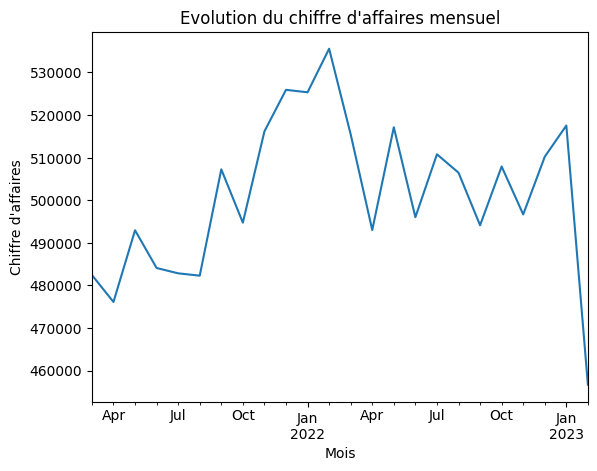

In [31]:
# evolution du chiffre d'affaires mensuel sur un graphique
CA_mois.plot(x='annee_mois', y='price')
plt.title('Evolution du chiffre d\'affaires mensuel')
plt.xlabel('Mois')
plt.ylabel('Chiffre d\'affaires')
plt.show()

In [32]:
# chiffre d'affaires annuel
CA_annee = merge.groupby('annee')['price'].sum()
CA_annee

,price
annee,
2021,4944760.98
2022,6108681.81
2023,974220.31


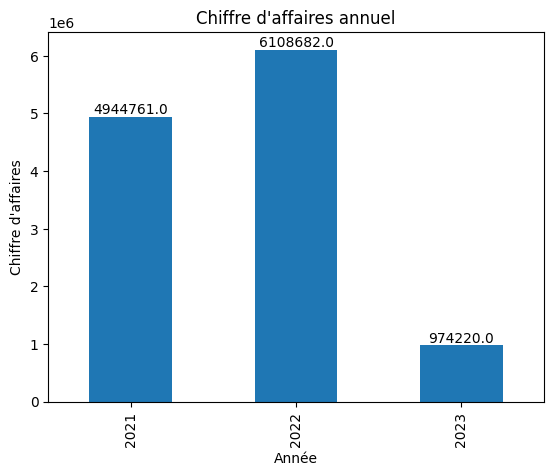

In [33]:
# chiffre d'affaires annuel sur un graphique
import matplotlib.pyplot as plt

ax = CA_annee.plot(kind='bar')

plt.title("Chiffre d'affaires annuel")
plt.xlabel("Année")
plt.ylabel("Chiffre d'affaires")

for i, valeur in enumerate(round(CA_annee)):
    ax.text(i, valeur, f"{valeur}", ha='center', va='bottom')

plt.show()


In [34]:
#chiffre d'affaire par jour de la semaine
CA_weekday = merge.groupby('weekday')['price'].sum()
CA_weekday


,price
weekday,
Friday,1705630.14
Monday,1739110.52
Saturday,1707864.79
Sunday,1717773.60
Thursday,1712845.47
Tuesday,1734560.41
Wednesday,1709878.17


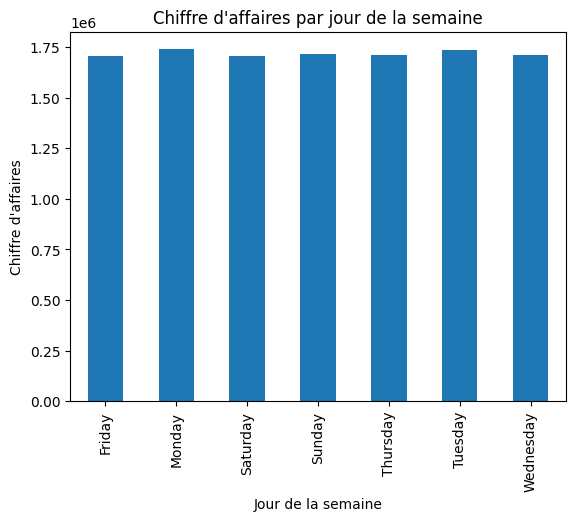

In [35]:
#visualisation
CA_weekday.plot(kind='bar')
plt.title('Chiffre d\'affaires par jour de la semaine')
plt.xlabel('Jour de la semaine')
plt.ylabel('Chiffre d\'affaires')
plt.show()

In [36]:
#chiffre d'affaire par semaine
CA_semaine = merge.groupby(pd.Grouper(key='date', freq='W'))['price'].sum()
CA_semaine

,price
date,
2021-03-07,110463.28
2021-03-14,105693.24
2021-03-21,112059.08
2021-03-28,109441.07
2021-04-04,107895.66
...,...
2023-02-05,113486.13
2023-02-12,112528.15
2023-02-19,114121.61


In [37]:
# visualisation graphique avec plotly express
fig = px.line(CA_semaine, x=CA_semaine.index, y=CA_semaine.values)
fig

In [38]:
#chiffre d'affaire par semaine en moyenne mobile
CA_semaine_moyenne = CA_semaine.rolling(7).mean()
CA_semaine_moyenne

,price
date,
2021-03-07,NaN
2021-03-14,NaN
2021-03-21,NaN
2021-03-28,NaN
2021-04-04,NaN
...,...
2023-02-05,114535.991429
2023-02-12,115217.475714
2023-02-19,115447.711429


In [39]:
#visualisation avec plotly
fig = px.line(CA_semaine_moyenne, x=CA_semaine_moyenne.index, y=CA_semaine_moyenne.values)
fig

In [40]:
#superposition des deux graphiques
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=CA_semaine.index, y=CA_semaine.values, mode='lines', name='CA Semaine'))
fig.add_trace(go.Scatter(x=CA_semaine_moyenne.index, y=CA_semaine_moyenne.values, mode='lines', name='Moyenne Mobile'))

fig.update_layout(title='CA Semaine + Moyenne Mobile', xaxis_title='Date', yaxis_title='Chiffre d\'affaires')
fig.show()

On remarque une hausse et une baisse, que s'est-il passé ?

Hypothèse : clients qui vont acheter des livres par rapport aux prix littéraire / rentrée des classes ?

In [41]:
#Analyse baisse sur octobre
octobre = merge.loc[merge.annee_mois== '2021-10', ['jour', 'price','categ']]
octobre

,jour,price,categ
195881,1,6.99,0
195882,1,17.41,1
195883,1,19.96,1
195884,1,22.09,1
195885,1,12.19,1
...,...,...,...
225898,31,12.99,0
225899,31,10.30,1
225900,31,20.99,1
225901,31,4.99,0


In [42]:
ca_octobre = pd.pivot_table(octobre, index = ['jour'], columns = 'categ', values = 'price',aggfunc=np.sum)
ca_octobre

/tmp/ipython-input-4222899710.py:1: FutureWarning:

The provided callable <function sum at 0x7ecb1bbc16c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



categ,0,1,2
jour,,,
1,6950.50,8997.88,3104.05
2,7141.01,13200.30,2041.12
3,6786.57,11535.55,2206.48
4,6533.60,10931.53,2746.08
5,6357.91,9359.45,3032.55
6,7546.58,10614.14,1944.11
7,6404.01,9175.15,1787.07
8,7069.53,8542.74,3137.82
9,6808.69,7811.74,2616.67


Text(0.5, 1.0, 'Evolution du C.A en octobre')

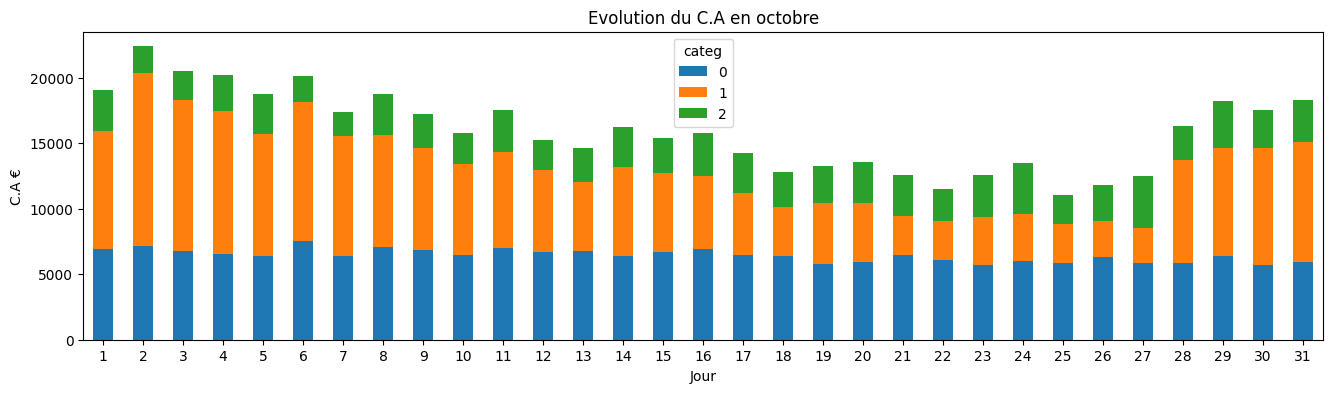

In [43]:
ca_octobre.plot.bar(figsize=(16,4), stacked=True)
plt.xlabel('Jour')
plt.xticks(rotation=0)
plt.ylabel('C.A €')

plt.title('Evolution du C.A en octobre')

In [44]:
#Analyse hausse sur septembre
septembre = merge.loc[merge.annee_mois== '2021-09', ['jour', 'price','categ']]
septembre

,jour,price,categ
162567,1,10.17,1
162568,1,9.99,0
162569,1,20.99,1
162570,1,16.99,0
162571,1,18.99,0
...,...,...,...
195876,30,5.46,0
195877,30,8.99,0
195878,30,19.99,0
195879,30,17.99,0


In [45]:
ca_septembre = pd.pivot_table(septembre, index = ['jour'], columns = 'categ', values = 'price',aggfunc=np.sum)
ca_septembre

/tmp/ipython-input-2955295825.py:1: FutureWarning:

The provided callable <function sum at 0x7ecb1bbc16c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



categ,0,1,2
jour,,,
1,6621.80,6328.02,2595.44
2,6561.12,6488.49,2966.37
3,7109.18,5975.43,3036.27
4,6746.60,5473.35,2551.28
5,6941.85,5879.26,2419.17
6,6760.50,6716.51,2472.88
7,7052.41,5872.16,3826.73
8,6823.27,6020.53,2630.70
9,7737.56,5734.05,3056.24


Text(0.5, 1.0, 'Evolution du C.A en septembre')

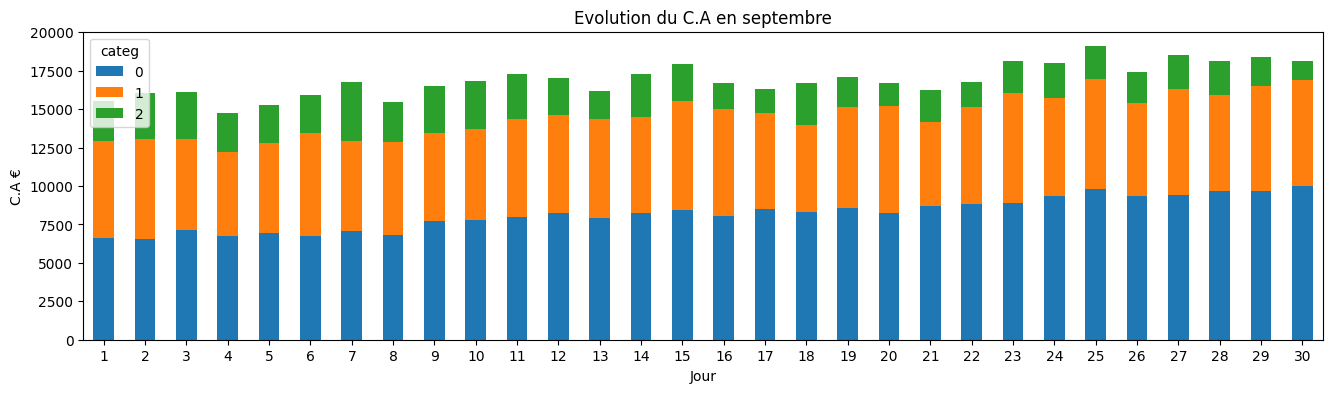

In [46]:
ca_septembre.plot.bar(figsize=(16,4), stacked=True)
plt.xlabel('Jour')
plt.xticks(rotation=0)
plt.ylabel('C.A €')

plt.title('Evolution du C.A en septembre')

In [47]:
#analyse hausse entre 23/01/2022 et 13/03/2022
hausse_2022 = merge.loc[
    (merge['annee_mois_jour'] >= '2022-01-01') &
    (merge['annee_mois_jour'] <= '2022-03-30'),
    ['annee_mois_jour', 'price', 'categ']
]


In [48]:
ca_hausse_2022 = pd.pivot_table(hausse_2022, index = ['annee_mois_jour'], columns = 'categ', values = 'price',aggfunc=np.sum)
ca_hausse_2022

/tmp/ipython-input-3379254025.py:1: FutureWarning:

The provided callable <function sum at 0x7ecb1bbc16c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.



categ,0,1,2
annee_mois_jour,,,
2022-01-01,6017.64,9084.41,2004.56
2022-01-02,5576.02,8023.84,2745.23
2022-01-03,5722.10,8314.43,3399.28
2022-01-04,5881.71,8261.47,3045.92
2022-01-05,5673.47,7359.97,2928.99
...,...,...,...
2022-03-26,5945.69,5011.96,5063.30
2022-03-27,6150.91,5684.78,4241.32
2022-03-28,6610.78,6947.04,5449.43


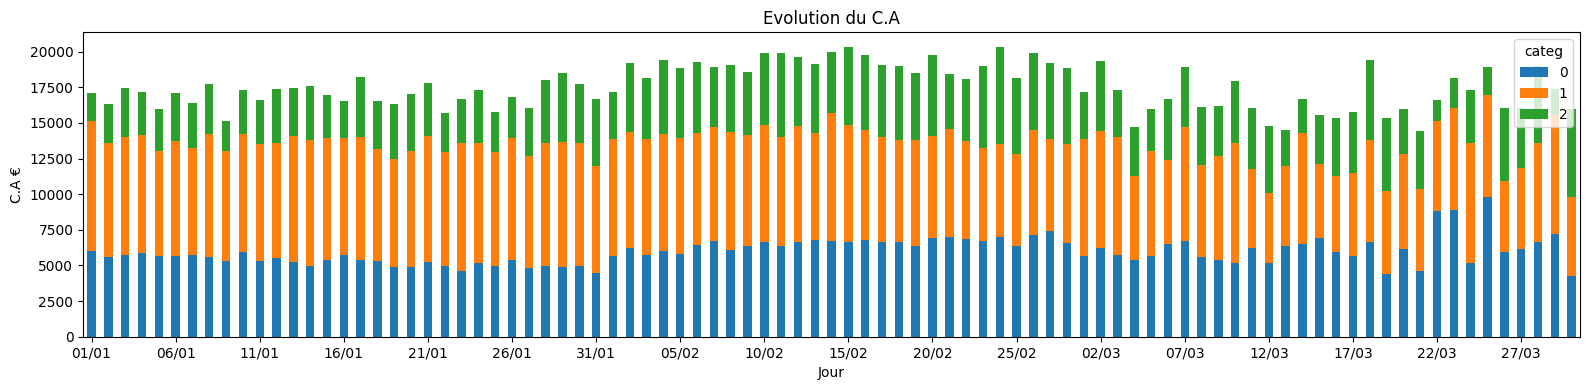

In [49]:
ax = ca_hausse_2022.plot.bar(
    figsize=(16, 4),
    stacked=True
)

ax.set_xlabel('Jour')
ax.set_ylabel('C.A €')
ax.set_title('Evolution du C.A')

# Réduire le nombre de labels
ticks = ax.get_xticks()[::5]
labels = ca_hausse_2022.index[::5].strftime('%d/%m')

ax.set_xticks(ticks)
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()



In [50]:
#CA par jour
CA_annee_mois_jour = merge.groupby('annee_mois_jour')['price'].sum()
CA_annee_mois_jour

,price
annee_mois_jour,
2021-03-01,16565.22
2021-03-02,15486.45
2021-03-03,15198.69
2021-03-04,15196.07
2021-03-05,17471.37
...,...
2023-02-24,15207.89
2023-02-25,15761.25
2023-02-26,16304.72


In [51]:
#visualisation avec plotly express
fig = px.line(CA_annee_mois_jour, x=CA_annee_mois_jour.index, y=CA_annee_mois_jour.values)
fig


In [52]:
#moyenne mobile du CA par jour
CA_annee_mois_jour_moyenne = CA_annee_mois_jour.rolling(7).mean()
CA_annee_mois_jour_moyenne

,price
annee_mois_jour,
2021-03-01,NaN
2021-03-02,NaN
2021-03-03,NaN
2021-03-04,NaN
2021-03-05,NaN
...,...
2023-02-24,16488.778571
2023-02-25,16006.747143
2023-02-26,16035.021429


In [53]:
#visualisation avec plotly
fig = px.line(CA_annee_mois_jour_moyenne, x=CA_annee_mois_jour_moyenne.index, y=CA_annee_mois_jour_moyenne.values)
fig

In [54]:
#Superposition

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=CA_annee_mois_jour.index, y=CA_annee_mois_jour.values, mode='lines', name='CA Quotidien'))
fig.add_trace(go.Scatter(x=CA_annee_mois_jour_moyenne.index, y=CA_annee_mois_jour_moyenne.values, mode='lines', name='Moyenne Mobile'))

fig.update_layout(title='CA Quotidien + Moyenne Mobile', xaxis_title='Date', yaxis_title='Chiffre d\'affaires')
fig.show()

In [55]:
#chiffre d'affaires par catégorie de livres
CA_categ = merge.groupby('categ')['price'].sum()
CA_categ

,price
categ,
0,4419730.97
1,4827657.11
2,2780275.02


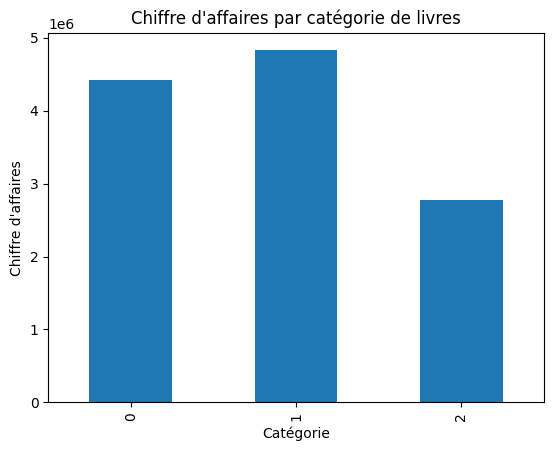

In [56]:
#visualisation graphique
CA_categ.plot(kind='bar')
plt.title('Chiffre d\'affaires par catégorie de livres')
plt.xlabel('Catégorie')
plt.ylabel('Chiffre d\'affaires')
plt.show()

In [57]:
#nombre de client par mois
nb_client_mois = merge.groupby('annee_mois')['client_id'].nunique()
nb_client_mois

,client_id
annee_mois,
2021-03-01,5676
2021-04-01,5674
2021-05-01,5644
2021-06-01,5659
2021-07-01,5672
2021-08-01,5642
2021-09-01,5693
2021-10-01,6190
2021-11-01,5875


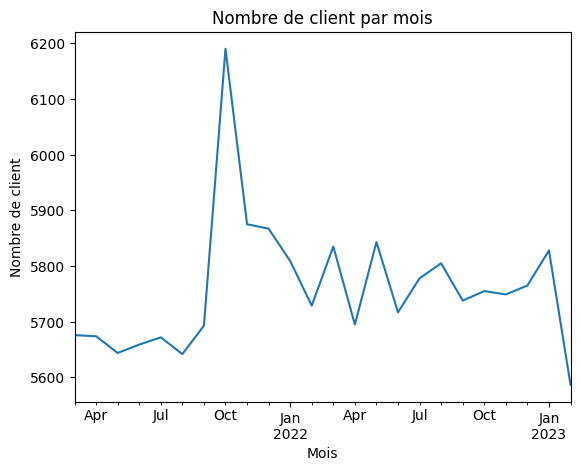

In [58]:
#visualisation graphique
nb_client_mois.plot(kind='line')
plt.title('Nombre de client par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre de client')
plt.show()

In [59]:
#nombre de transaction
nb_transaction = merge['session_id'].nunique()
nb_transaction

345505

In [60]:
#nombre de produit
nb_produit = merge['id_prod'].nunique()
nb_produit

3265

In [61]:
# nombre de vente par produit
nb_vente_produit = merge.groupby('id_prod')['session_id'].count()
nb_vente_produit

,session_id
id_prod,
0_0,1242
0_1,487
0_10,22
0_100,3
0_1000,432
...,...
2_95,4
2_96,598
2_97,13


# TOP/FLOP des livres

In [62]:
# top 10 qui génèrent le plus de CA
top_10 = merge.groupby('id_prod')['price'].sum().nlargest(10)
top_10

,price
id_prod,
2_159,94893.50
2_135,69334.95
2_112,65407.76
2_102,60736.78
2_209,56971.86
1_395,56617.47
1_369,56136.60
2_110,53846.25
1_383,53834.43


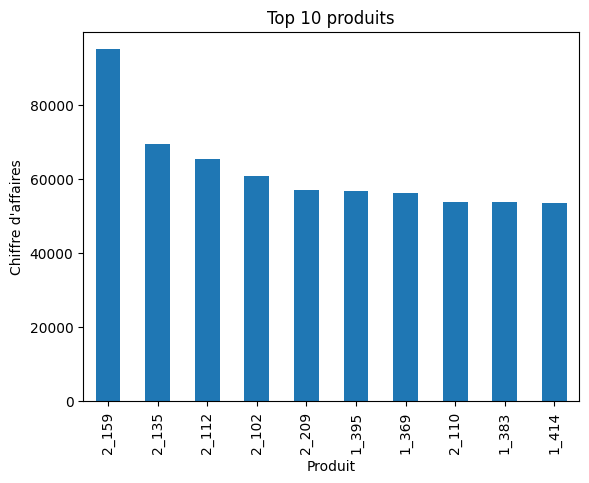

In [63]:
#visualisation graphique
top_10.plot(kind='bar')
plt.title('Top 10 produits')
plt.xlabel('Produit')
plt.ylabel('Chiffre d\'affaires')
plt.show()

In [64]:
# flop 10
flop_10 = merge.groupby('id_prod')['price'].sum().nsmallest(10)
flop_10

,price
id_prod,
0_1539,0.99
0_1284,1.38
0_1653,1.98
0_1601,1.99
0_541,1.99
0_807,1.99
0_1728,2.27
0_1498,2.48
0_898,2.54


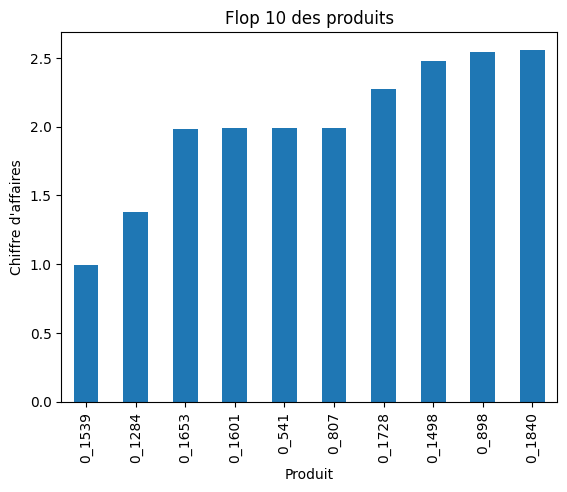

In [65]:
#visualisation
flop_10.plot(kind='bar')
plt.title('Flop 10 des produits')
plt.xlabel('Produit')
plt.ylabel('Chiffre d\'affaires')
plt.show()

In [66]:
# répartion CA par catégorie
CA_categ = merge.groupby('categ')['price'].sum()
CA_categ

,price
categ,
0,4419730.97
1,4827657.11
2,2780275.02


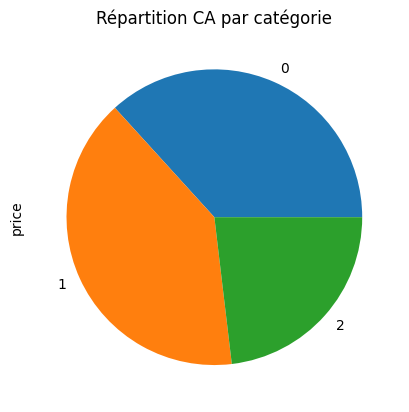

In [67]:
#visualisation
CA_categ = CA_categ / CA_categ.sum() * 100
CA_categ.plot(kind='pie')
plt.title('Répartition CA par catégorie')
plt.show()

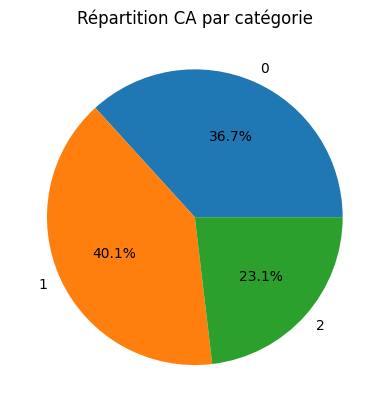

In [68]:
CA_categ.plot.pie(autopct='%1.1f%%', title='Répartition CA par catégorie')
plt.ylabel('')
plt.show()

In [69]:
# répartion du volume des ventes par catégorie
volume_categ = merge.groupby('categ')['session_id'].count()
volume_categ

,session_id
categ,
0,415459
1,235592
2,36483


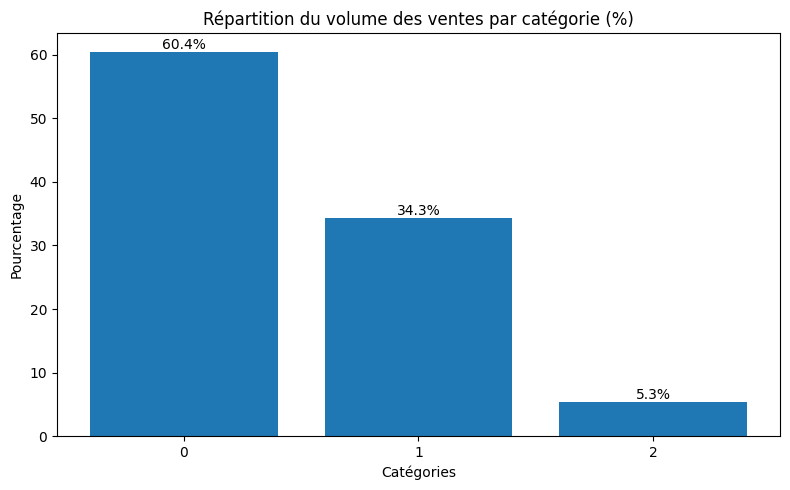

In [70]:
#visualisation graphique
import matplotlib.pyplot as plt

volume_categ_pct = volume_categ / volume_categ.sum() * 100

volume_categ_pct = volume_categ_pct.sort_index()

plt.figure(figsize=(8, 5))

positions = range(len(volume_categ_pct))
bars = plt.bar(positions, volume_categ_pct)

plt.xticks(positions, volume_categ_pct.index)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.title('Répartition du volume des ventes par catégorie (%)')
plt.xlabel('Catégories')
plt.ylabel('Pourcentage')
plt.tight_layout()
plt.show()

In [71]:
#Répartition des prix de ventes par catégorie en boite à moustache
import plotly.express as px

fig = px.box(merge, x="categ", y="price", orientation='v')
fig.show()

# Clients

In [72]:
#Répartition des clients par âge
merge['age'] = 2021 - merge['birth']
merge['age'].value_counts()

,count
age,
41,47702
33,25245
42,25101
43,24905
35,23693
...,...
89,312
86,278
91,238


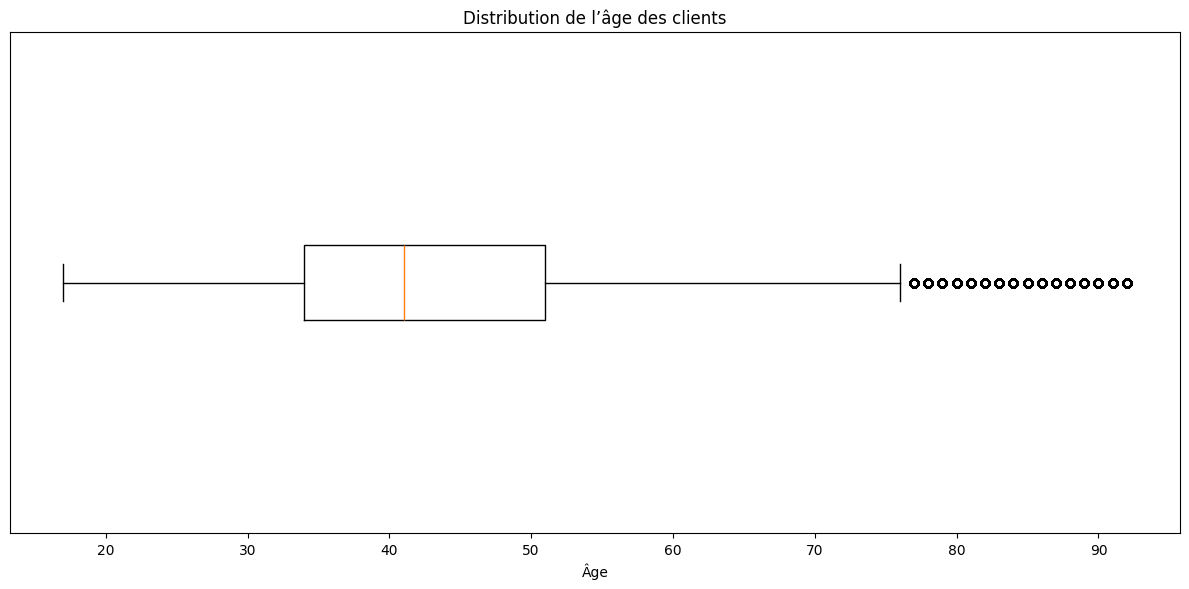

In [73]:
#graphique boite a moustache
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.boxplot(
    merge['age'].dropna(),
    vert=False,
    showfliers=True
)

plt.title('Distribution de l’âge des clients')
plt.xlabel('Âge')
plt.yticks([])

plt.tight_layout()
plt.show()


Top 10 clients

In [74]:
#les clients les plus fidèles
clients_plus_roulants = merge.groupby('client_id')['session_id'].nunique().nlargest(10)
clients_plus_roulants

,session_id
client_id,
c_1609,10997
c_3454,5571
c_4958,3851
c_6714,2620
c_8526,167
c_1637,165
c_2265,165
c_669,163
c_8510,162


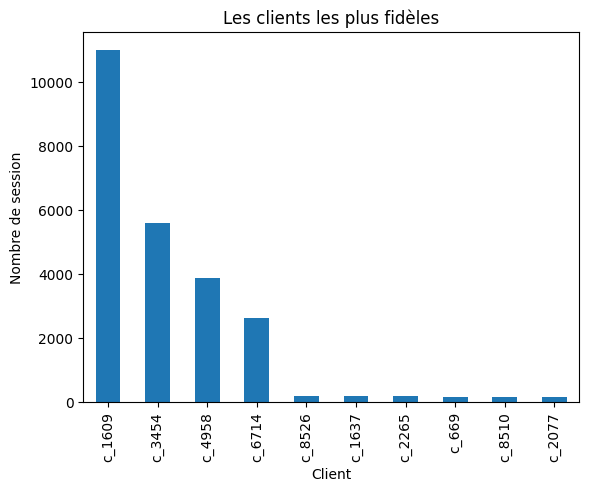

In [75]:
#visualisation
clients_plus_roulants.plot(kind='bar')
plt.title('Les clients les plus fidèles')
plt.xlabel('Client')
plt.ylabel('Nombre de session')
plt.show()

In [76]:
#les clients qui font le plus de CA
clients_plus_CA = merge.groupby('client_id')['price'].sum().nlargest(10)
clients_plus_CA

,price
client_id,
c_1609,326039.89
c_4958,290227.03
c_6714,153918.60
c_3454,114110.57
c_1570,5285.82
c_3263,5276.87
c_2140,5260.18
c_2899,5214.05
c_7319,5155.77


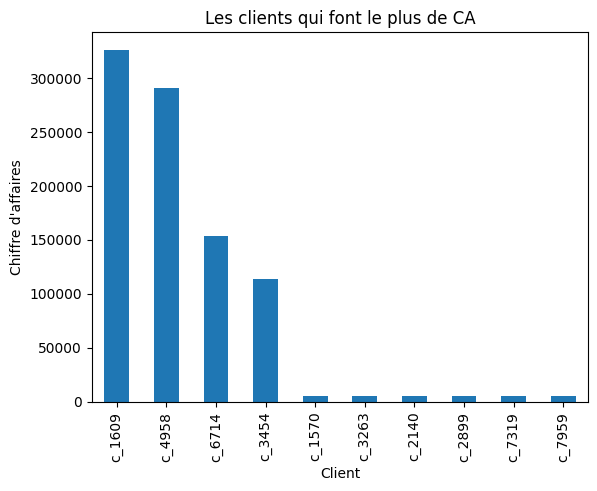

In [77]:
#visualisation
clients_plus_CA.plot(kind='bar')
plt.title('Les clients qui font le plus de CA')
plt.xlabel('Client')
plt.ylabel('Chiffre d\'affaires')
plt.show()

On remarque qu'il y a des clients BtB donc on les isole

In [78]:
# isolement des clients btb (clients c_1609, c_4958, c_6714, c_3454)
btb_ids = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
merge_btb = merge[merge['client_id'].isin(btb_ids)]
merge_btb


,id_prod,date,session_id,client_id,annee,mois,jour,annee_mois,weekday,annee_mois_jour,sex,birth,price,categ,age
6,0_1304,2021-03-01 00:07:04.371179,s_7,c_1609,2021,3,1,2021-03-01,Monday,2021-03-01,m,1980,5.86,0,41
13,0_1159,2021-03-01 00:11:57.832228,s_7,c_1609,2021,3,1,2021-03-01,Monday,2021-03-01,m,1980,7.99,0,41
50,0_1431,2021-03-01 01:08:49.803921,s_33,c_3454,2021,3,1,2021-03-01,Monday,2021-03-01,m,1969,10.99,0,52
78,0_1425,2021-03-01 01:56:41.944044,s_46,c_1609,2021,3,1,2021-03-01,Monday,2021-03-01,m,1980,12.99,0,41
88,0_1469,2021-03-01 02:12:21.294004,s_53,c_1609,2021,3,1,2021-03-01,Monday,2021-03-01,m,1980,14.99,0,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687482,0_1333,2023-02-28 22:40:24.405750,s_348416,c_6714,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1968,5.99,0,53
687494,1_392,2023-02-28 23:04:51.081903,s_348416,c_6714,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1968,18.11,1,53
687496,2_13,2023-02-28 23:08:40.035146,s_348403,c_4958,2023,2,28,2023-02-01,Tuesday,2023-02-28,m,1999,50.99,2,22
687498,1_183,2023-02-28 23:10:49.235323,s_348416,c_6714,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1968,24.99,1,53


In [79]:
#dataframe sans les clients btb
merge_nobtb = merge[~merge['client_id'].isin(btb_ids)]
merge_nobtb


,id_prod,date,session_id,client_id,annee,mois,jour,annee_mois,weekday,annee_mois_jour,sex,birth,price,categ,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021,3,1,2021-03-01,Monday,2021-03-01,f,1967,11.99,0,54
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021,3,1,2021-03-01,Monday,2021-03-01,m,1960,19.37,0,61
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021,3,1,2021-03-01,Monday,2021-03-01,m,1988,4.50,0,33
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021,3,1,2021-03-01,Monday,2021-03-01,f,1989,6.55,0,32
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021,3,1,2021-03-01,Monday,2021-03-01,f,1956,16.49,0,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1996,21.92,1,25
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1994,48.99,2,27
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,2023,2,28,2023-02-01,Tuesday,2023-02-28,f,1985,26.99,1,36
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,2023,2,28,2023-02-01,Tuesday,2023-02-28,m,1953,8.99,0,68


Part des clients BtB sur le CA

In [80]:
#pourcentage du CA par client BtB sur le CA en décroissant
CA_par_client = merge.groupby('client_id')['price'].sum().sort_values(ascending=False)
CA_total = CA_par_client.sum()
pourcentage_CA = (CA_par_client / CA_total * 100).round(2)
df_CA = pourcentage_CA.reset_index()
df_CA.columns = ['client_id', 'pourcentage_CA']
df_CA_btb = df_CA[df_CA['client_id'].isin(btb_ids)]
df_CA_btb

,client_id,pourcentage_CA
0,c_1609,2.71
1,c_4958,2.41
2,c_6714,1.28
3,c_3454,0.95


([<matplotlib.patches.Wedge at 0x7ecad1441e50>,
 [Text(0.44095827425683704, 1.0077478853187598, 'c_1609'),
  Text(-1.0769300147321668, -0.22410208247353602, 'c_4958'),
  Text(0.2310021410438817, -1.075471064619194, 'c_6714'),
  Text(1.0105546958126417, -0.43448729184064705, 'c_3454')],
 [Text(0.2405226950491838, 0.5496806647193235, '36.9%'),
  Text(-0.5874163716720908, -0.12223749953101963, '32.8%'),
  Text(0.12600116784211726, -0.5866205807013785, '17.4%'),
  Text(0.5512116522614409, -0.23699306827671654, '12.9%')])

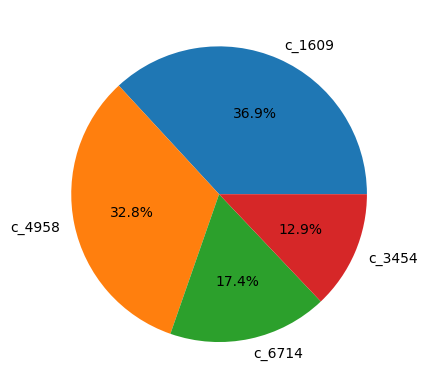

In [81]:
#visualisation camembert
fig, ax = plt.subplots()
ax.pie(df_CA_btb['pourcentage_CA'], labels=df_CA_btb['client_id'], autopct='%1.1f%%')

In [82]:
#Top 10 clients sans btb
clients_plus_CA_nobtb = merge_nobtb.groupby('client_id')['price'].sum().nlargest(10)
clients_plus_CA_nobtb

,price
client_id,
c_1570,5285.82
c_3263,5276.87
c_2140,5260.18
c_2899,5214.05
c_7319,5155.77
c_7959,5135.75
c_1422,5131.36
c_7421,5097.18
c_8026,5082.58


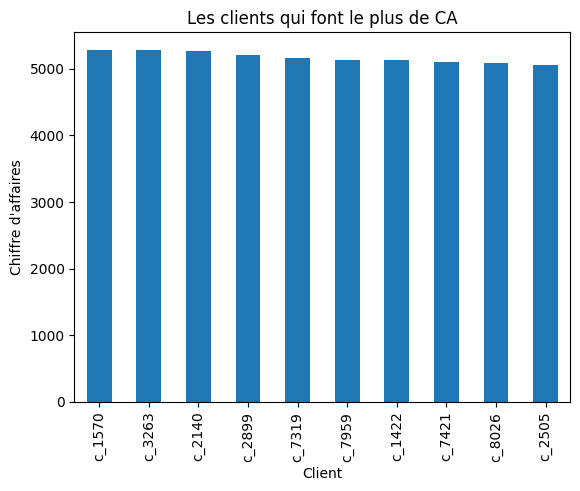

In [83]:
#graphique
clients_plus_CA_nobtb.plot(kind='bar')
plt.title('Les clients qui font le plus de CA')
plt.xlabel('Client')
plt.ylabel('Chiffre d\'affaires')
plt.show()

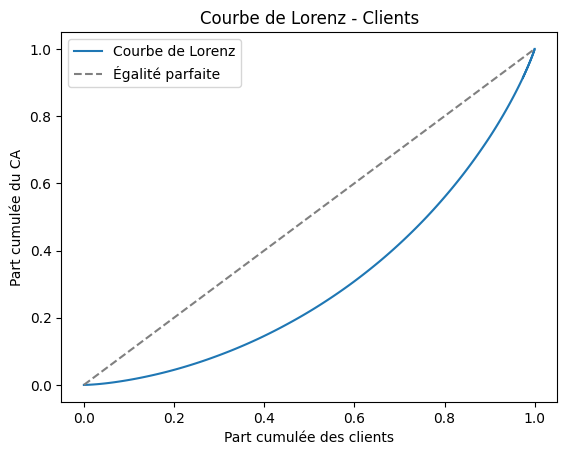

In [84]:
#Courbe de lorenz
# Calcul du chiffre d'affaires total par client
CA_par_client = merge_nobtb.groupby('client_id')['price'].sum().sort_values()

# Part cumulée du CA
CA_cumulee = CA_par_client.cumsum() / CA_par_client.sum()

# Axe x : part cumulée des clients
x = np.arange(1, len(CA_cumulee)+1) / len(CA_cumulee)

# Tracer la courbe de Lorenz
plt.plot(x, CA_cumulee.values, drawstyle='steps-post', label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Égalité parfaite')
plt.xlabel('Part cumulée des clients')
plt.ylabel('Part cumulée du CA')
plt.title('Courbe de Lorenz - Clients')
plt.legend()
plt.show()

# Requete Julie

In [85]:
#lien entre le genre d'un client et les catégories des livres achetés
genre_categca = merge_nobtb.pivot_table(index='sex', columns='categ', values='id_prod', aggfunc='count')
genre_categca

categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


Tout d'abord, on fait un test de Chi2 pour savoir si deux variables sont liées

In [86]:
from scipy.stats import chi2_contingency


In [87]:
chi2_contingency(genre_categca)

Chi2ContingencyResult(statistic=np.float64(22.66856665178056), pvalue=np.float64(1.1955928116587024e-05), dof=2, expected_freq=array([[201574.89662481, 114822.13191434,  17096.97146086],
       [185706.10337519, 105782.86808566,  15751.02853914]]))

Les deux variables sont dépendantes car p-value< 5%

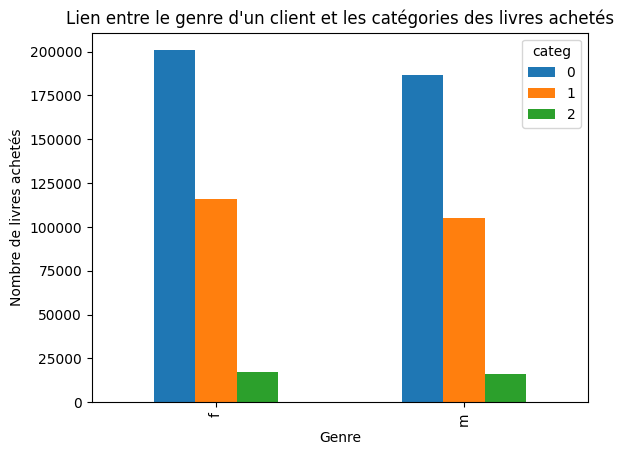

In [88]:
#visualisation
genre_categca.plot(kind='bar')
plt.title('Lien entre le genre d\'un client et les catégories des livres achetés')
plt.xlabel('Genre')
plt.ylabel('Nombre de livres achetés')
plt.show()

Cependant, visuellement on ne le voit pas

Est ce que les femmes/hommes privilégient la meme catégorie ?

In [89]:
#probabilité d'achat par catégorie selon le sexe
proba_achat_cat_sexe_1 = genre_categca.div(genre_categca.sum(axis=1), axis=0)
proba_achat_cat_sexe_1

categ,0,1,2
sex,,,
f,0.602089,0.346996,0.050915
m,0.606978,0.341375,0.051647


In [90]:
#probabilité d'achat par catégorie selon le sexe en colonne
proba_achat_cat_sexe_2 = proba_achat_cat_sexe_1.div(proba_achat_cat_sexe_1.sum(axis=0), axis=1)
proba_achat_cat_sexe_2

categ,0,1,2
sex,,,
f,0.497978,0.504083,0.496434
m,0.502022,0.495917,0.503566


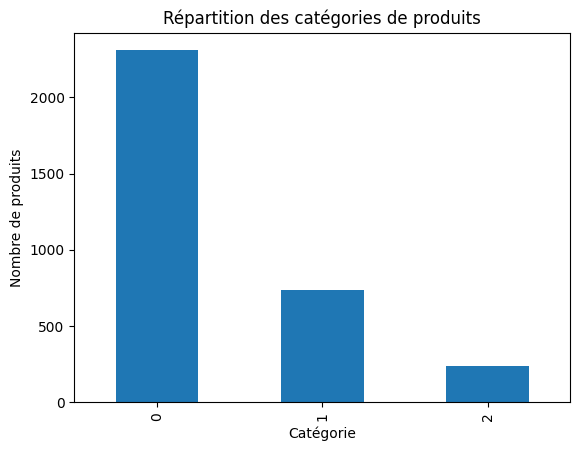

In [91]:
products['categ'].value_counts().plot(kind='bar')
plt.title('Répartition des catégories de produits')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de produits')
plt.show()

voir proportion de livre par catégorie
(2 fois plus de chance d'acheter une catégorie qu'une autre)

en fait il y a une correlation mais les deux sexes priviligient la categorie 1

In [92]:
#lien entre l'age des clients et le montant total des achats
merge_nobtb['age_client'] = merge_nobtb['annee'] - merge_nobtb['birth']
achats_age = merge_nobtb.groupby(['age_client'])['price'].sum()

/tmp/ipython-input-2858275435.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



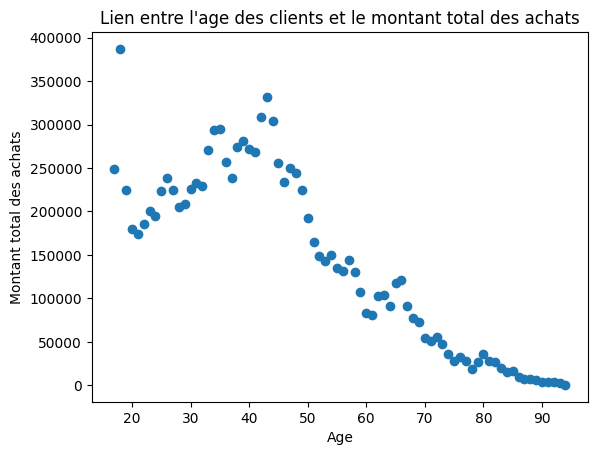

In [93]:
#visualisation en nuage de points
plt.scatter(achats_age.index, achats_age.values)
plt.title('Lien entre l\'age des clients et le montant total des achats')
plt.xlabel('Age')
plt.ylabel('Montant total des achats')
plt.show()


Visuellement on voit qu'il y a une relation entre l'age et le montant moyen des achats

Comment le démontrer mathématiquement ?

On choisit spearman car la courbe n'est pas linéaire

In [94]:
spearmanr(achats_age.index, achats_age.values)

SignificanceResult(statistic=np.float64(-0.88042337409426), pvalue=np.float64(2.4326850391487356e-26))

Il y a une corrélation négative (montant diminue avec l'age) et un lien significatif

In [95]:
#lien entre l'age des clients et la fréquence d'achat
achats_age_freq = merge_nobtb.groupby(['age_client'])['session_id'].count()

<function matplotlib.pyplot.show(close=None, block=None)>

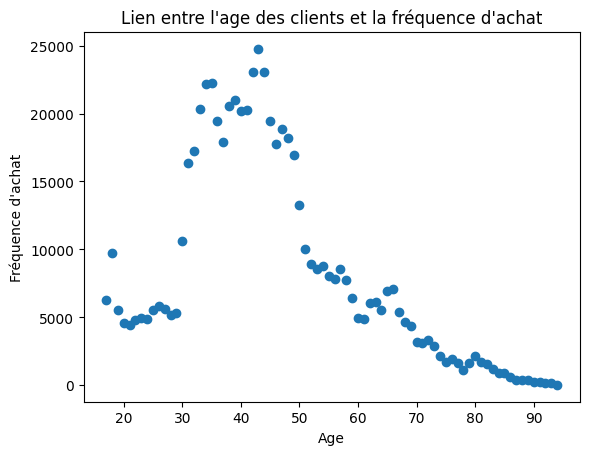

In [96]:
#visualisation
plt.scatter(achats_age_freq.index, achats_age_freq.values)
plt.title('Lien entre l\'age des clients et la fréquence d\'achat')
plt.xlabel('Age')
plt.ylabel('Fréquence d\'achat')
plt.show

visuellement on voit que les plus jeunes ont une meilleure fréquence d'achat

pas linéaire donc spearman

In [97]:
# spearman
spearmanr(achats_age_freq.index, achats_age_freq.values)

SignificanceResult(statistic=np.float64(-0.6968601019233931), pvalue=np.float64(1.3811203038339299e-12))

corrélation négative et lien significatif

les jeunes clients achètent beaucoup plus souvent que les plus âgés

In [98]:
#lien entre l'age des clients et la taille du panier moyen
taille_panier = merge_nobtb.groupby(['age_client','session_id'])["price"].sum().reset_index()
panier_moyen = taille_panier.groupby(['age_client'])["price"].mean().reset_index()
panier_moyen


,age_client,price
0,17,69.714127
1,18,70.008598
2,19,70.624278
3,20,69.895511
4,21,70.069016
...,...,...
73,90,25.395247
74,91,30.265328
75,92,23.504296
76,93,24.600233


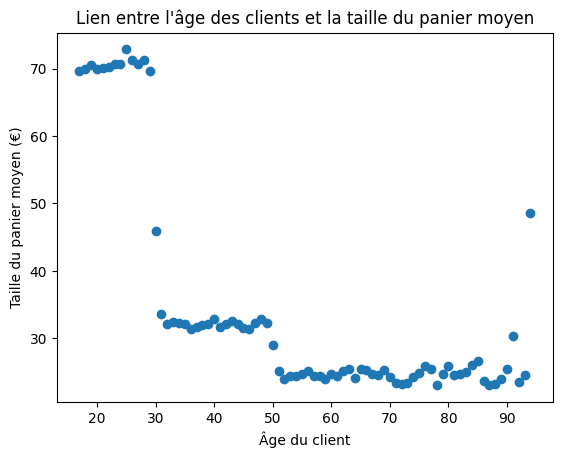

In [99]:
#visualisation

import matplotlib.pyplot as plt

plt.scatter(panier_moyen['age_client'], panier_moyen['price'])
plt.title("Lien entre l'âge des clients et la taille du panier moyen")
plt.xlabel("Âge du client")
plt.ylabel("Taille du panier moyen (€)")
plt.show()


In [100]:
#pearson
pearsonr(panier_moyen['age_client'], panier_moyen['price'])

PearsonRResult(statistic=np.float64(-0.7230363666864204), pvalue=np.float64(7.713512019225711e-14))

plus l’âge augmente, plus le panier moyen diminue

In [101]:
#lien entre l'age des clients et la catégorie des livres achetés
age_categ = merge_nobtb.groupby(['categ'])['age_client'].mean().reset_index()
age_categ

,categ,age_client
0,0,43.446784
1,1,47.325840
2,2,25.652764


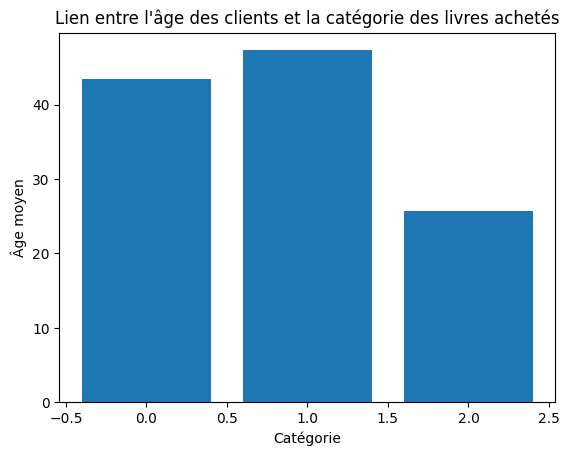

In [102]:
#visualisation en bar
plt.bar(age_categ['categ'], age_categ['age_client'])
plt.title("Lien entre l'âge des clients et la catégorie des livres achetés")
plt.xlabel("Catégorie")
plt.ylabel("Âge moyen")
plt.show()

anova illicite donc utiliser kruskal wallis

car anova doit avoir plusieurs conditions et cette relation ne l'a pas ( il faut le meme nombre de personne par groupe de personnes)

In [103]:
from scipy.stats import kruskal

g0 = merge_nobtb[merge_nobtb['categ'] == 0]['age_client']
g1 = merge_nobtb[merge_nobtb['categ'] == 1]['age_client']
g2 = merge_nobtb[merge_nobtb['categ'] == 2]['age_client']

stat, p = kruskal(g0, g1, g2)

print("Statistique H :", stat)
print("p-value :", p)


Statistique H : 71283.57583245283
p-value : 0.0


La p-value est très largement inférieure à 0,05
L’âge des clients diffère significativement selon la catégorie de livres achetés.

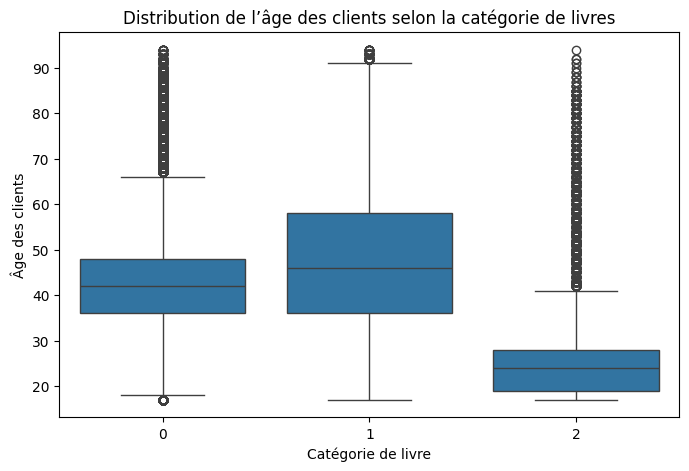

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x='categ', y='age_client', data=merge_nobtb)

plt.xlabel("Catégorie de livre")
plt.ylabel("Âge des clients")
plt.title("Distribution de l’âge des clients selon la catégorie de livres")

plt.show()


L’âge moyen des clients n’est pas du tout le même selon la catégorie de livre achetée.

Il existe un lien très fort entre l’âge et la catégorie achetée.